In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ollama
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

In [2]:
# Load dataset
df = pd.read_csv('train.csv')
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [4]:
df.describe()

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


In [5]:
df.shape

(7613, 5)

In [6]:
df.tail()

,id,keyword,location,text,target
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1
7612,10873,NaN,NaN,The Latest: More Homes Razed by Northern Calif...,1


In [7]:
# Check missing values in the dataset 
print(df.isnull().sum())

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [8]:
# Keep only text and target columns
df = df[['text', 'target']]
df.head()

,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


In [9]:
# Count values in target column 
print(df['target'].value_counts())

target
0    4342
1    3271
Name: count, dtype: int64


In [10]:
# Preprocessing 
# Text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)   # remove links
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation/numbers
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [11]:
# Use Hermes 3 to add LLM_Flag column
def get_llm_flag(tweet):
    response = ollama.chat(model='hermes3',
        messages=[{'role':'user','content':f'Is this tweet describing a real physical disaster? Answer YES or NO only: {tweet}'}])
    return 1 if 'YES' in response['message']['content'].upper() else 0

In [12]:
# Load progress if exists
try:
    df = pd.read_csv('progress.csv')
    print('Resuming from saved progress')
except FileNotFoundError:
    print('Starting fresh')

LLM_flags = df.get('LLM_Flag', [None]*len(df)).tolist()

for i, tweet in enumerate(df['clean_text']):
    if pd.isnull(LLM_flags[i]):   # only process if not done yet
        flag = get_llm_flag(tweet)
        LLM_flags[i] = flag

        # Save progress every 100 tweets
        if (i+1) % 100 == 0:
            print(f"Processed {i+1} tweets")
            df['LLM_Flag'] = LLM_flags
            df.to_csv('progress.csv', index=False)

# Final save
df['LLM_Flag'] = LLM_flags
df.to_csv('final_results.csv', index=False)
print('All tweets processed and saved.')

Resuming from saved progress
All tweets processed and saved.


In [13]:
df.head()

,text,target,clean_text,LLM_Flag
0,Our Deeds are the Reason of this #earthquake M...,1,our deeds are the reason of this earthquake ma...,1.0
1,Forest fire near La Ronge Sask. Canada,1,forest fire near la ronge sask canada,0.0
2,All residents asked to 'shelter in place' are ...,1,all residents asked to shelter in place are be...,1.0
3,"13,000 people receive #wildfires evacuation or...",1,people receive wildfires evacuation orders in...,1.0
4,Just got sent this photo from Ruby #Alaska as ...,1,just got sent this photo from ruby alaska as s...,1.0


In [14]:
# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=5000)
X_text = vectorizer.fit_transform(df['clean_text'])

# Combine TF-IDF with LLM_Flag
X = np.hstack((X_text.toarray(), df[['LLM_Flag']].values))
y = df['target']

In [15]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Check Train/Test data shape
print('Train data shape:', X_train.shape)
print('Test data shape:', X_test.shape)

Train data shape: (6090, 5001)
Test data shape: (1523, 5001)


In [17]:
# Train Bernoulli Naive Bayes
nb_model = BernoulliNB(alpha=0.5)
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.5
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [18]:
y_pred_nb = nb_model.predict(X_test)

In [19]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [20]:
y_pred_dt = dt_model.predict(X_test)

In [21]:
# Evaluation
# Naive Bayes 
print('Naive Bayes Accuracy:', accuracy_score(y_test, y_pred_nb))

f1_nb = f1_score(y_test, y_pred_nb)
print('Naive Bayes F1-Score:', f1_nb)
print('\nNaive Bayes Classification Report:\n', classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8128693368351937
Naive Bayes F1-Score: 0.765045342126958

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.84       874
           1       0.82      0.71      0.77       649

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.80      1523
weighted avg       0.81      0.81      0.81      1523



In [22]:
# Decision Tree
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))

f1_dt = f1_score(y_test, y_pred_dt)
print('Decision Tree F1-Score:', f1_dt)
print('\nDecision Tree Classification Report:\n', classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7524622455679579
Decision Tree F1-Score: 0.6343355965082444

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.94      0.81       874
           1       0.86      0.50      0.63       649

    accuracy                           0.75      1523
   macro avg       0.79      0.72      0.72      1523
weighted avg       0.78      0.75      0.74      1523



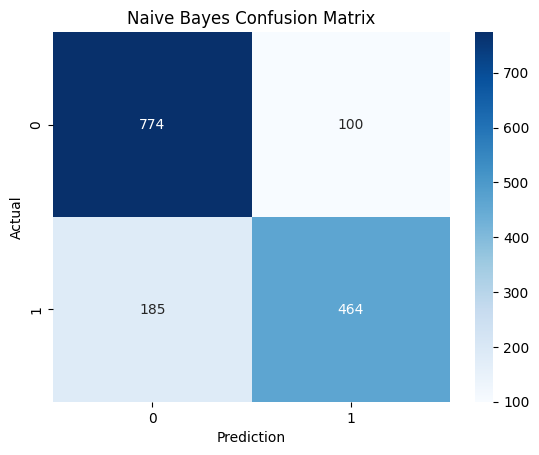

In [23]:
# Naive Bayes Confusion Matrix 
nb_cm = confusion_matrix(y_test, y_pred_nb) 
sns.heatmap(nb_cm, annot=True, fmt='d',cmap='Blues') 
plt.title('Naive Bayes Confusion Matrix') 
plt.xlabel('Prediction') 
plt.ylabel('Actual') 
plt.show()

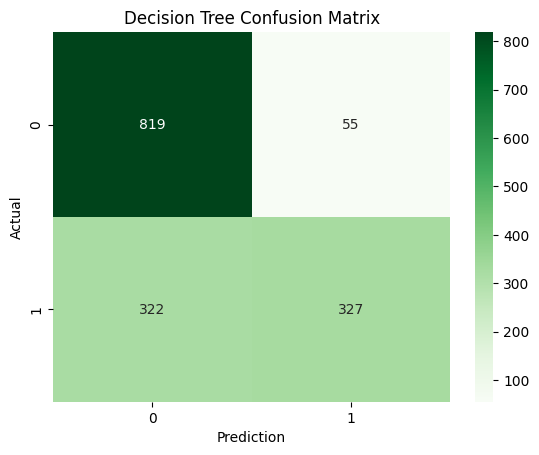

In [24]:
# Decision Tree Confusion Matrix 
dt_cm = confusion_matrix(y_test, y_pred_dt) 
sns.heatmap(dt_cm, annot=True, fmt='d',cmap='Greens') 
plt.title('Decision Tree Confusion Matrix') 
plt.xlabel('Prediction') 
plt.ylabel('Actual') 
plt.show()

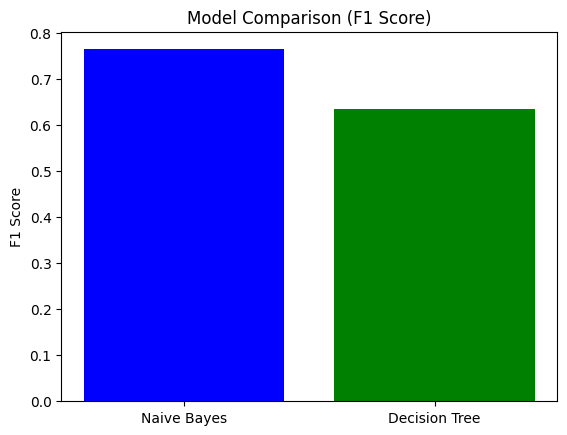

In [25]:
# F1 Score Comparison Bar Chart
plt.bar(['Naive Bayes', 'Decision Tree'], [f1_nb, f1_dt], color=['blue','green'])
plt.ylabel('F1 Score')
plt.title('Model Comparison (F1 Score)')
plt.show()

In [26]:
def predict_with_both_models(text, vectorizer, nb_model, dt_model):
    # Clean the text
    cleaned = clean_text(text)

    # Convert to TF-IDF using the SAME fitted vectorizer
    tfidf_vec = vectorizer.transform([cleaned]).toarray()   

    # Generate LLM_Flag for this tweet
    flag = get_llm_flag(cleaned)   
    flag_array = np.array([[flag]]) 

    # Combine TF-IDF + LLM_Flag 
    features = np.hstack((tfidf_vec, flag_array))  

    # Predict with both models
    pred_nb = nb_model.predict(features)[0]
    pred_dt = dt_model.predict(features)[0]

    # Print results 
    print(f"Tweet: {text}")
    print('Naive Bayes Prediction:', 'Non-disaster' if pred_nb == 0 else 'Disaster')
    print('Decision Tree Prediction:', 'Non-disaster' if pred_dt == 0 else 'Disaster')

In [27]:
# Example tweet
predict_with_both_models('This song is the bomb', vectorizer, nb_model, dt_model)

Tweet: This song is the bomb
Naive Bayes Prediction: Non-disaster
Decision Tree Prediction: Non-disaster


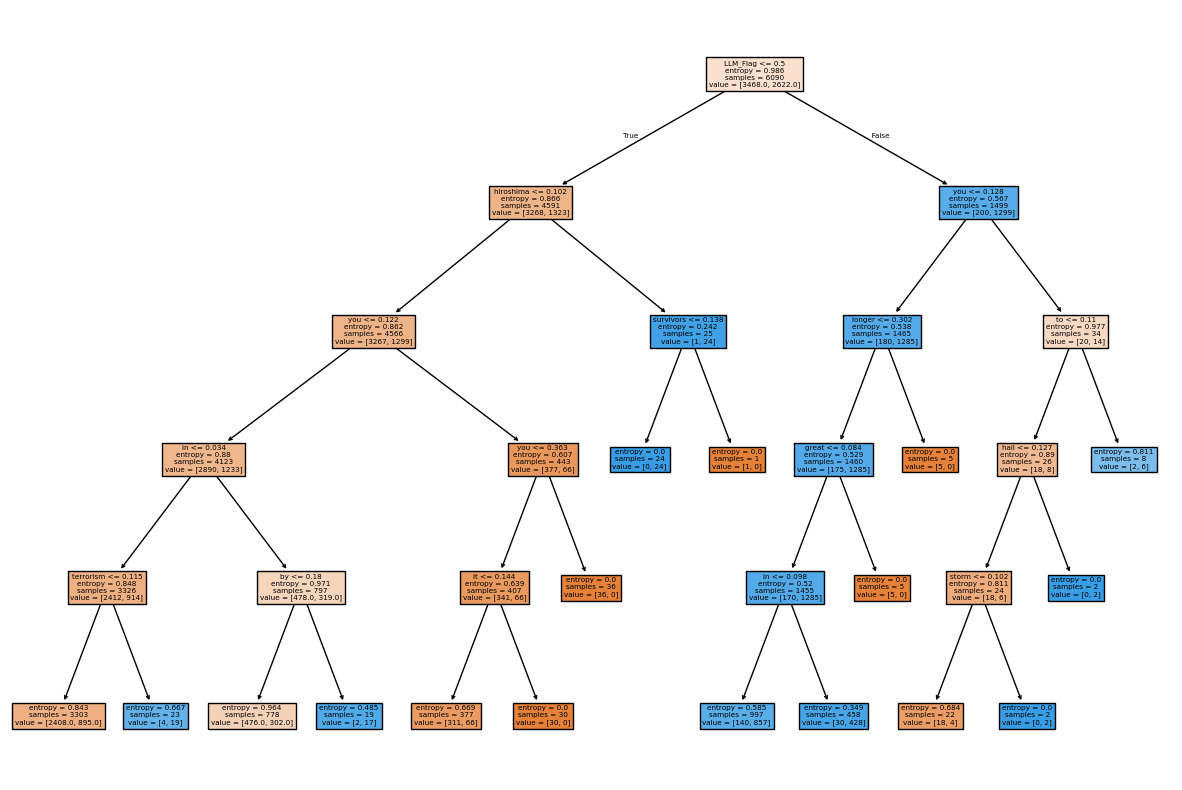

In [28]:
# Plot Decision Tree
plt.figure(figsize=(15,10))
plot_tree(dt_model, filled=True, feature_names=vectorizer.get_feature_names_out().tolist() + ['LLM_Flag'])
plt.show()